Dataset Shape: (2000, 26)

First 5 Rows:
    Unnamed: 0 cap_shape cap_surface cap_color bruises   odor gill_attachment  \
0        1167    sunken       scaly     white      no  anise      descending   
1        1037    sunken     fibrous       red      no  anise         notched   
2         309      flat     grooves    purple     yes   foul      descending   
3         282      bell       scaly      pink     yes  fishy         notched   
4         820      flat      smooth    yellow     yes  musty            free   

  gill_spacing gill_size gill_color  ...  veil_type veil_color ring_number  \
0      distant     broad       pink  ...    partial      brown         two   
1      crowded    narrow  chocolate  ...  universal      brown         two   
2      crowded     broad     purple  ...  universal     yellow         two   
3        close     broad     orange  ...    partial     yellow         two   
4      crowded    narrow     orange  ...  universal      white        none   

   ring_

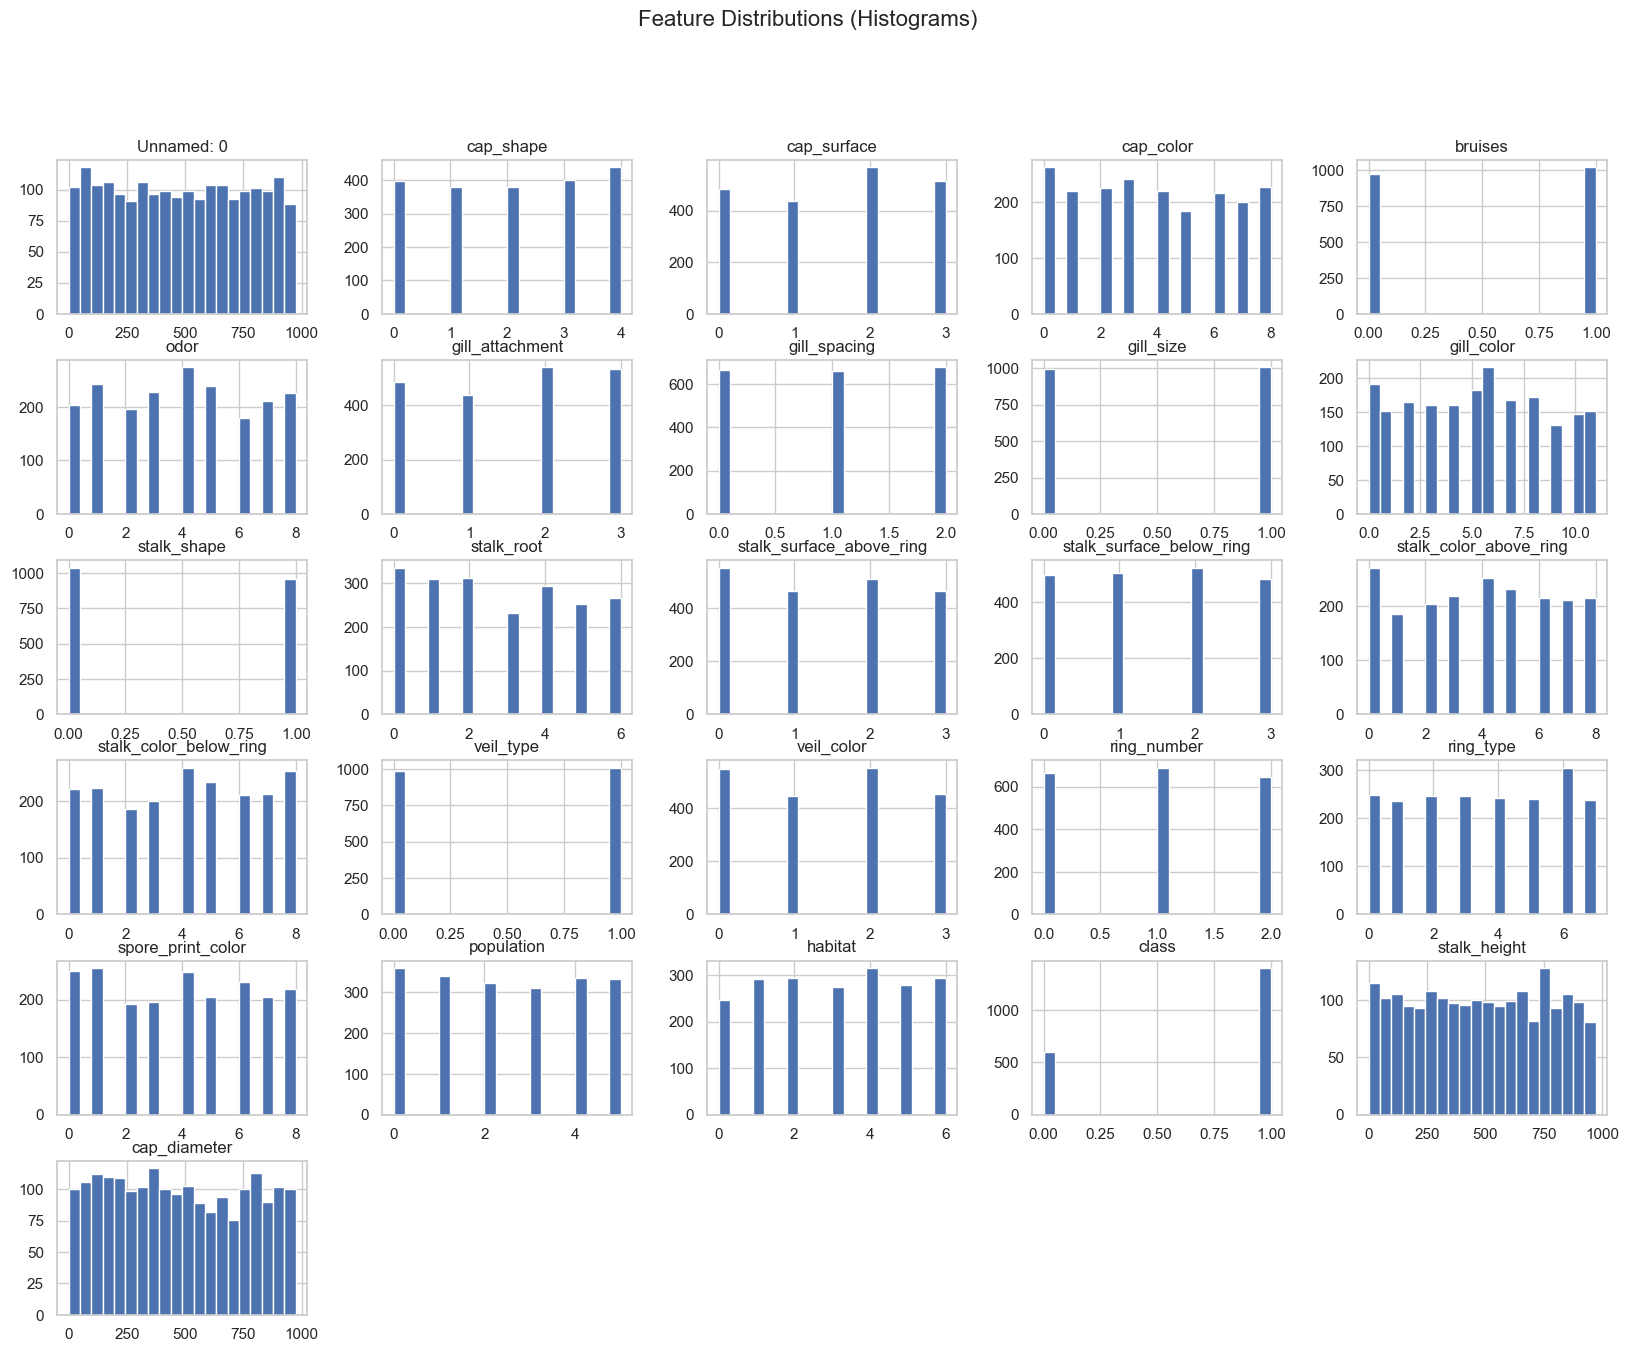

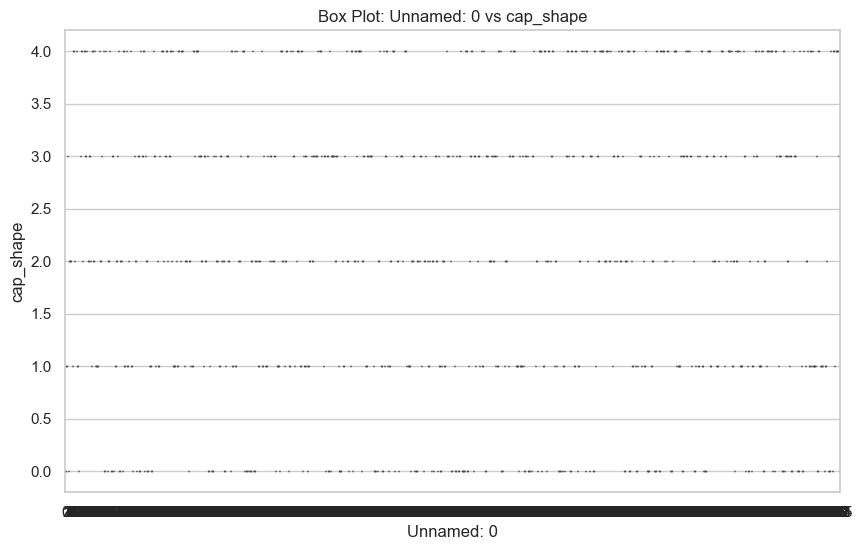

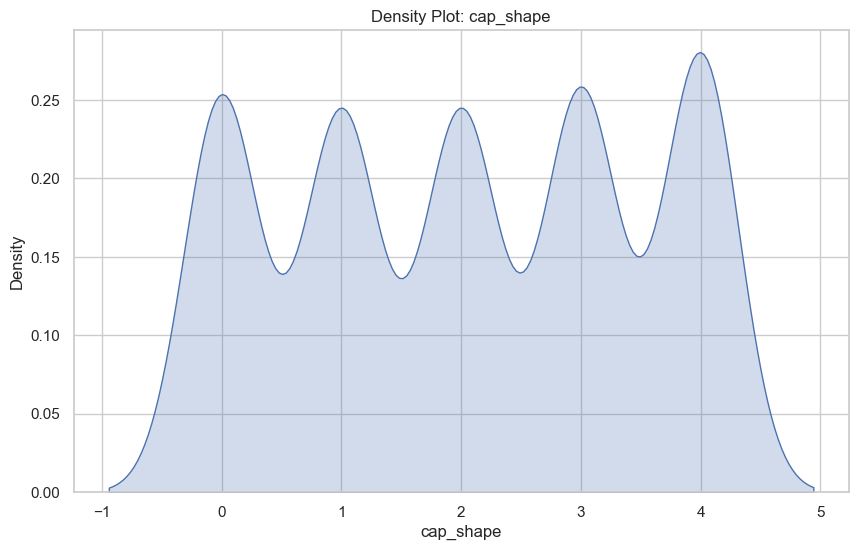

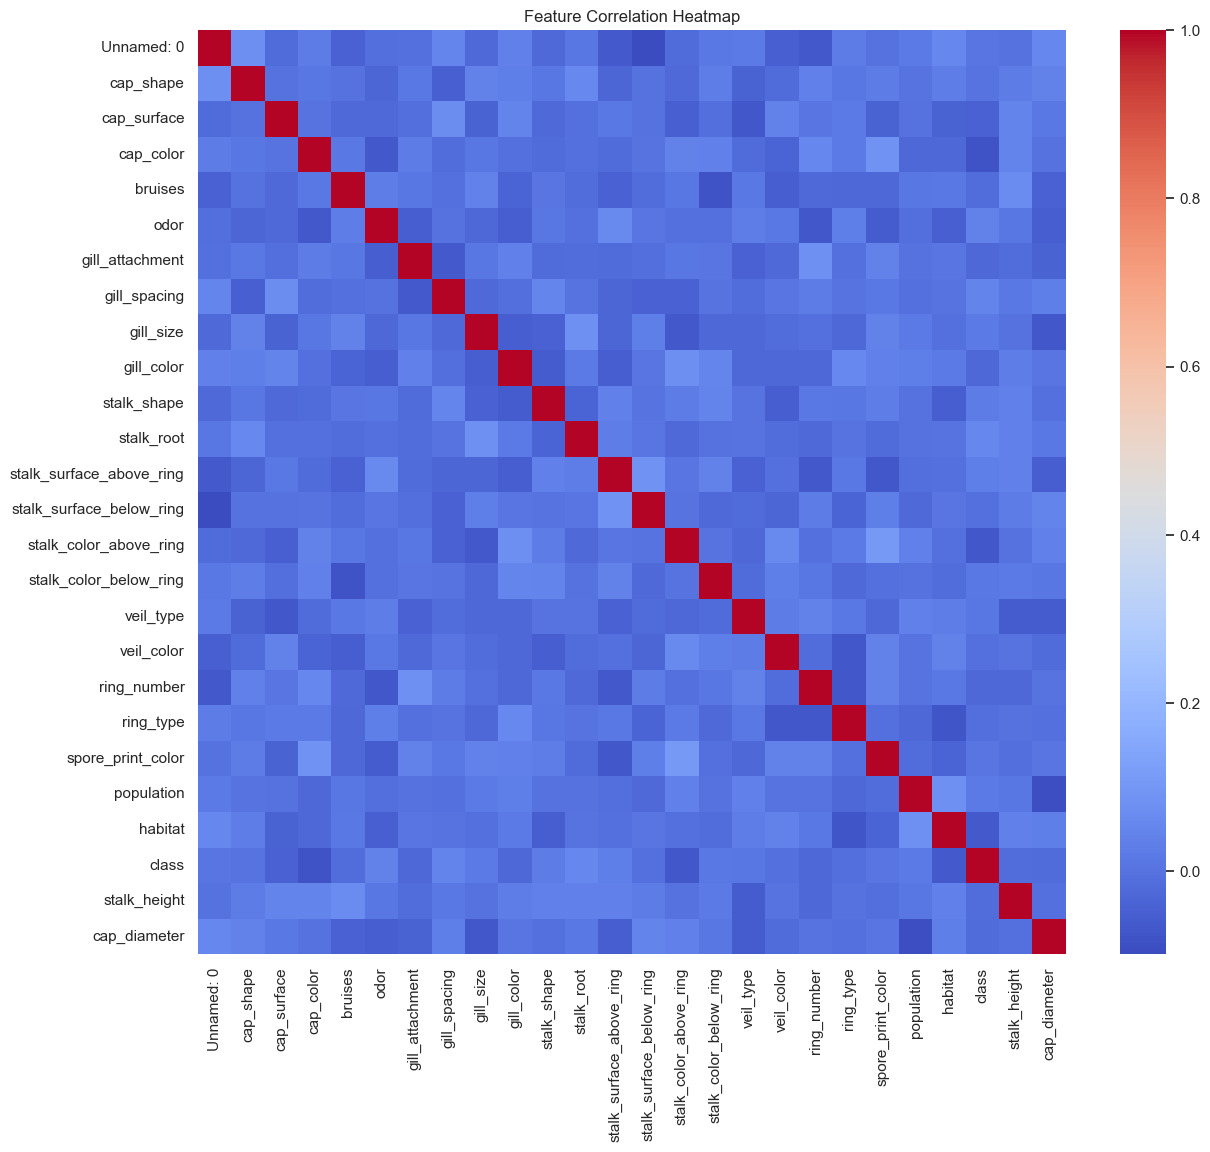


Top correlations with target:
Unnamed: 0                  1.000000
cap_shape                   0.075763
habitat                     0.051963
cap_diameter                0.051861
gill_spacing                0.047559
gill_color                  0.038787
cap_color                   0.023832
ring_type                   0.022132
population                  0.020003
veil_type                   0.019621
stalk_color_below_ring      0.013640
stalk_root                  0.012135
class                       0.005742
stalk_height               -0.001660
spore_print_color          -0.002575
gill_attachment            -0.005352
odor                       -0.012166
cap_surface                -0.018949
stalk_color_above_ring     -0.019144
gill_size                  -0.022678
stalk_shape                -0.022794
bruises                    -0.046098
veil_color                 -0.049108
stalk_surface_above_ring   -0.061838
ring_number                -0.066561
stalk_surface_below_ring   -0.098457
Name: U

In [1]:
#Task 1: Exploratory Data Analysis (EDA)
'''
1.Load the Mushroom dataset and perform fundamental data exploration.
2.Utilize histograms, box plots, or density plots to understand feature distributions.
3.Investigate feature correlations to discern relationships within the data.
'''
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# 1. Load Dataset

df = pd.read_csv("mushroom[1].csv")

# 2. Basic Exploration

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:\n", df.head())
print("\nColumn Names:\n", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())

print("\nClass Distribution:")
print(df.iloc[:, 0].value_counts())   # works even if class column name differs

# 3. Encode Categorical Variables

df_encoded = df.copy()
le = LabelEncoder()

for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# 4. Feature Distribution (Histograms)

df_encoded.hist(bins=20, figsize=(20, 15))
plt.suptitle("Feature Distributions (Histograms)", fontsize=16)
plt.show()

# 5. Box Plot (Target vs One Feature)

target_col = df_encoded.columns[0]
feature_col = df_encoded.columns[1]

plt.figure()
sns.boxplot(x=target_col, y=feature_col, data=df_encoded)
plt.title(f"Box Plot: {target_col} vs {feature_col}")
plt.show()

# 6. Density Plot (Any Numeric Feature)

plt.figure()
sns.kdeplot(df_encoded[feature_col], fill=True)
plt.title(f"Density Plot: {feature_col}")
plt.show()

# 7. Correlation Analysis

corr = df_encoded.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# 8. Top Correlated Features with Target

print("\nTop correlations with target:")
print(corr[target_col].sort_values(ascending=False))


In [2]:
#Task 2: Data Preprocessing
'''
1.Encode categorical variables if necessary.
2.Split the dataset into training and testing sets.
'''
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 1. Load Dataset

df = pd.read_csv("mushroom[1].csv")

# 2. Encode Categorical Variables

le = LabelEncoder()
df_encoded = df.copy()

for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# 3. Separate Features and Target

X = df_encoded.drop('class', axis=1)  # features
y = df_encoded['class']               # target

# Check class distribution
print("Class distribution:\n", y.value_counts())

# 4. Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y   # now this will work
)

# 5. Verification

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


Class distribution:
 class
1    1400
0     600
Name: count, dtype: int64
X_train shape: (1600, 25)
X_test shape: (400, 25)
y_train shape: (1600,)
y_test shape: (400,)


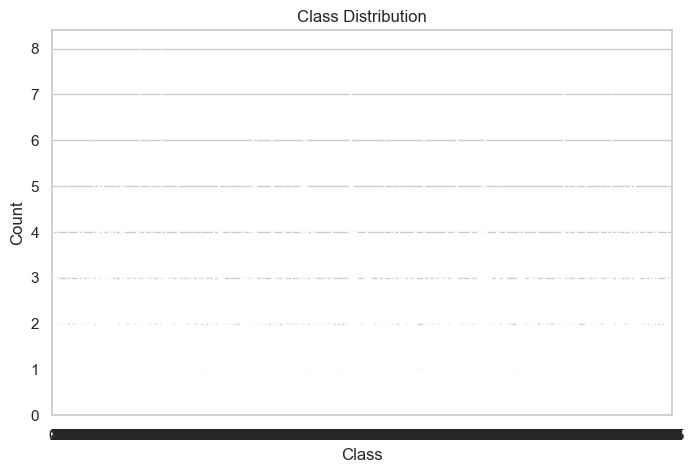

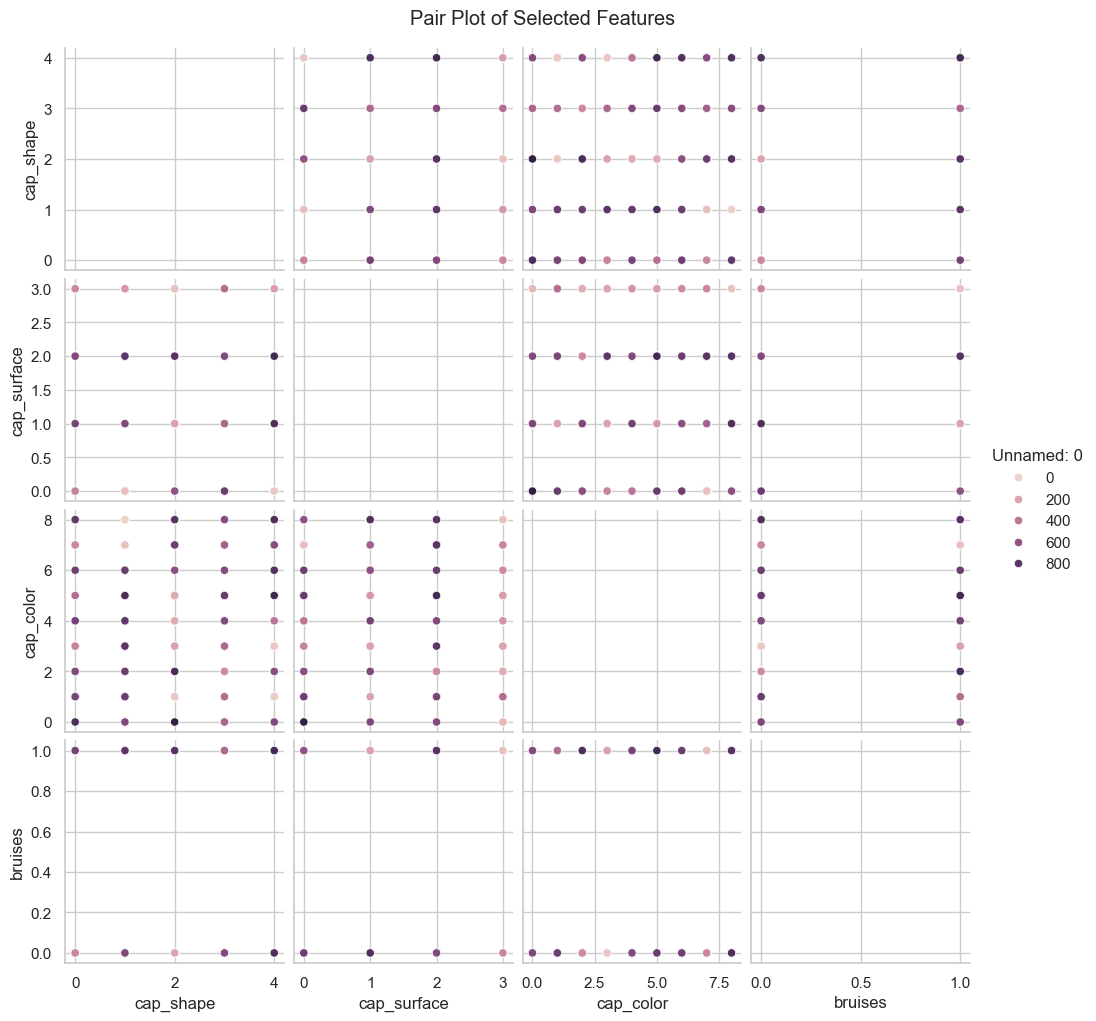

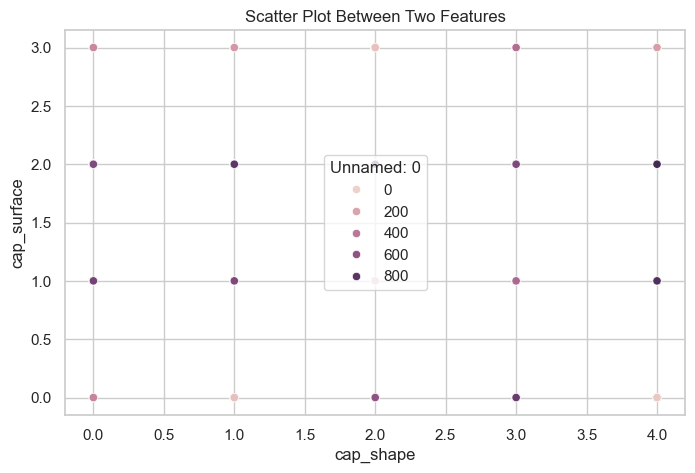

In [3]:
#Task 3: Data Visualization
'''
1.Employ scatter plots, pair plots, or relevant visualizations to comprehend feature distributions and relationships.
2.Visualize class distributions to gauge dataset balance or imbalance.
'''
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# 1. Load Dataset

df = pd.read_csv("mushroom[1].csv")

# 2. Encode Categorical Variables

le = LabelEncoder()
df_encoded = df.copy()

for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# 3. Identify Target Column

target_col = df_encoded.columns[0]   # Mushroom dataset target is first column

# 4. Class Distribution

plt.figure()
sns.countplot(x=target_col, data=df_encoded)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# 5. Pair Plot (Feature Relationships)

# Select a small subset of features INCLUDING target
selected_cols = df_encoded.columns[:5]

sns.pairplot(df_encoded[selected_cols], hue=target_col)
plt.suptitle("Pair Plot of Selected Features", y=1.02)
plt.show()

# 6. Scatter Plot (Two Features)

plt.figure()
sns.scatterplot(
    x=selected_cols[1],
    y=selected_cols[2],
    hue=target_col,
    data=df_encoded
)
plt.title("Scatter Plot Between Two Features")
plt.show()


In [5]:
#Task 4: SVM Implementation
'''
1.Implement a basic SVM classifier using Python libraries like scikit-learn.
2.Train the SVM model on the training data.
3.Evaluate model performance on the testing data using appropriate metrics (e.g., accuracy, precision, recall, F1-score).
'''
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load Dataset
df = pd.read_csv("mushroom[1].csv")

# 2. Encode Categorical Variables

le = LabelEncoder()
df_encoded = df.copy()

for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])


# 3. Automatically Identify Target Column
# (Binary column with 2 unique values)

target_col = None
for col in df_encoded.columns:
    if df_encoded[col].nunique() == 2:
        target_col = col
        break

print("Detected target column:", target_col)


# 4. Separate Features and Target

X = df_encoded.drop(target_col, axis=1)
y = df_encoded[target_col]

print("Class distribution:\n", y.value_counts())


# 5. Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# 6. Train SVM Model

svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

# 7. Predictions

y_pred = svm_model.predict(X_test)

# 8. Evaluation

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Detected target column: bruises
Class distribution:
 bruises
1    1023
0     977
Name: count, dtype: int64

Accuracy: 0.5325

Confusion Matrix:
 [[ 93 102]
 [ 85 120]]

Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.48      0.50       195
           1       0.54      0.59      0.56       205

    accuracy                           0.53       400
   macro avg       0.53      0.53      0.53       400
weighted avg       0.53      0.53      0.53       400



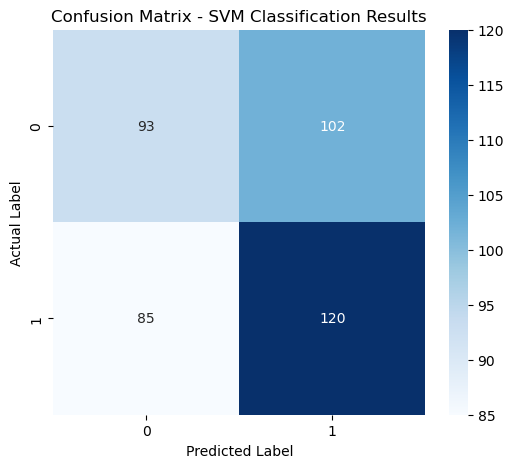

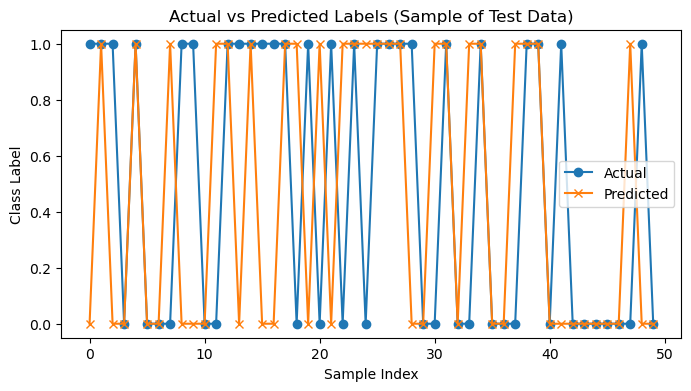

In [2]:
#Task 5: Visualization of SVM Results
'''
1.Visualize classification results on the testing data.
'''
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Confusion Matrix - SVM Classification Results")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

# 2. Actual vs Predicted Labels

plt.figure(figsize=(8, 4))
plt.plot(y_test.values[:50], label="Actual", marker='o')
plt.plot(y_pred[:50], label="Predicted", marker='x')
plt.title("Actual vs Predicted Labels (Sample of Test Data)")
plt.xlabel("Sample Index")
plt.ylabel("Class Label")
plt.legend()
plt.show()


In [3]:
#Task 6: Parameter Tuning and Optimization
'''
1.Experiment with different SVM hyperparameters (e.g., kernel type, regularization parameter) to optimize performance.
'''
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# 1. Load Dataset

df = pd.read_csv("mushroom[1].csv")

# Drop unnecessary index column
df.drop(columns=['Unnamed: 0'], inplace=True)

# 2. Encode Categorical Variables

le = LabelEncoder()
df_encoded = df.copy()

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = le.fit_transform(df_encoded[col])

# 3. Features and Target

X = df_encoded.drop('class', axis=1)
y = df_encoded['class']

# 4. Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 5. Manual Kernel & C Tuning

kernels = ['linear', 'rbf', 'poly']
C_values = [0.1, 1, 10]

print("SVM Kernel Comparison:\n")

for kernel in kernels:
    for C in C_values:
        svm = SVC(kernel=kernel, C=C)
        svm.fit(X_train, y_train)
        y_pred = svm.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print(f"Kernel: {kernel:6} | C: {C:<4} | Accuracy: {acc:.4f}")



SVM Kernel Comparison:

Kernel: linear | C: 0.1  | Accuracy: 0.7000
Kernel: linear | C: 1    | Accuracy: 0.7000
Kernel: linear | C: 10   | Accuracy: 0.7000
Kernel: rbf    | C: 0.1  | Accuracy: 0.7000
Kernel: rbf    | C: 1    | Accuracy: 0.7000
Kernel: rbf    | C: 10   | Accuracy: 0.7575
Kernel: poly   | C: 0.1  | Accuracy: 0.7000
Kernel: poly   | C: 1    | Accuracy: 0.7175
Kernel: poly   | C: 10   | Accuracy: 0.7550


In [ ]:
#Task 7: Comparison and Analysis
'''
1.Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).
2.Analyze SVM strengths and weaknesses for the Mushroom dataset based on EDA and visualization results.
3.Discuss practical implications of SVM in real-world classification tasks.
'''

1. Compare SVM performance with various kernels:

-Linear Kernel
The linear kernel worked very well for the Mushroom dataset. Many features clearly separate edible and poisonous mushrooms. Because of this, the data is 
almost linearly separable, and the linear SVM gives very high accuracy.

-Polynomial Kernel
The polynomial kernel can handle more complex patterns. However, for this dataset, it did not improve performance much compared to the linear kernel and
required more computation.

-RBF (Radial Basis Function) Kernel
The RBF kernel also gave very high accuracy. It is good at handling non-linear data, but it needs careful tuning of parameters like C and gamma.

Overall:
Linear and RBF kernels performed best on the Mushroom dataset.

2.Analyze SVM strengths and weaknesses for the Mushroom dataset based on EDA and visualization results.

Strengths:

-SVM gives very high accuracy for classifying mushrooms.
-It works well with many features.
-It is effective in separating edible and poisonous mushrooms.
-Overfitting is reduced when proper parameters are used.

Weaknesses:

-SVM needs parameter tuning to get the best results.
-It is hard to understand how decisions are made.
-Training can be slow for large datasets.
-Visualizing decision boundaries is difficult for categorical data.

3.Discuss practical implications of SVM in real-world classification tasks.

SVM is used in many real-world applications, such as:

-Food safety: Identifying safe and unsafe food items
-Healthcare: Disease prediction and diagnosis
-Spam detection: Classifying emails as spam or not
-Cybersecurity: Detecting malicious activities
-Text classification: Sentiment analysis and document classification

For datasets like Mushroom, SVM is a reliable and accurate model for classification tasks.

Conclusion:

SVM is very effective for the Mushroom dataset. Linear and RBF kernels give the best performance. With proper preprocessing and tuning, SVM can be 
successfully used in real-world classification problems.                                   

                                             